# Cluster analysis of Colorado 2016 general election data at the precinct level #

In this notebook, I will use scikit-learn to perform a clutering analysis of Colorado's 2016 election data.

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.patheffects
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("fivethirtyeight")

from sklearn.preprocessing import StandardScaler  # standardize the features
from sklearn.cluster import KMeans
from itertools import cycle, islice
from pandas.plotting import parallel_coordinates
from sklearn.decomposition import PCA  # reduce the dimensions
from sklearn.cluster import SpectralClustering

# Step 1: Acquiring Data #
The goal of this project is to have a better understanding of the voting patterns of American voters. Here are the broad questions I hope I would be better equipped to answer when it's done.
* Do American voters fall in groups more nuanced than just left and right? 
* Which candidate and issue do each subgroup of voters tend to vote for? 
* Is it possible to predict how Americans would vote given the subgroup they belong to?
* Can we predict how Americans would vote based on their past voting behaviors?
* Which group should the advocates of a certain measure target to achieve the best results?

There are a lot of datasets of the US election results open for public. I chose Colorado's 2016 general election results for the following reasons.
* It's the most recent election and hence the most relevant to the future.
* It's accompanied with a very good blue book detailing the ballot information, what each referendum is about, etc.
* It's collected down to the precinct level. There is a big enough pool (over 3000 precincts in the entire states) for us to find meaning subgroup.
* It contains both the national election results and the results of the state referenda. 
* Colorado is traditionally a purple state. Though it is less of a battleground in recent years, its voters are expected to be more diverse than states like California and West Virginia. As of July 1, 2017, the ratio of democratic, republican and unaffiliated voters in Colorado is roughly 1:1:1.

I've found many other states (California, North Carolina, Maryland, Virginia, Washington, Oregon and Florida) that have their election results readily online, but they are often incomplete for my purposes, either lacking in the results of their state referenda (i.e., they only reveal the results for national offices, which tend to be binary), precinct level data, or (self-)explanatory column/variable names that are hard for me to figure out otherwise. For the follow up study, I'll need to do more scouting and spend more time on transforming these data into useable shape. I'll stick to Colorado for this preliminary analysis.

In [2]:
co2016 = pd.read_csv("datasets/Colorado_general_2016_precinct.csv", low_memory=False)
to2016 = pd.read_csv("datasets/Colorado_turnout_2016_precinct.csv", low_memory=False)

## Step 2: Exploring Data ##
The CSV file is obtained from the website of Colorado's secretary of state (https://www.sos.state.co.us/pubs/elections/Results/Archives.html).

In [3]:
co2016.shape

(226031, 11)

In [4]:
to2016.shape

(3010, 10)

The way the table is organized is very unintuitive. The feature names are given in one column "Office/Issue/Judgeship" and the rows do not correspond to samples (i.e., precincts). The numerical data (i.e., the votes) are divided in three columns: Candidate Votes, Yes Votes, and No Votes. The last two are reserved for the state referenda only.

In [5]:
co2016.head()

,State,Year,Election Type,County,Precinct,Office/Issue/Judgeship,Candidate,Party,Candidate Votes,Yes Votes,No Votes
0,Colorado,2016,G,Adams,4253001245,President/Vice President,Hillary Clinton / Tim Kaine,Democratic Party,63,0.0,0.0
1,Colorado,2016,G,Adams,4253001245,President/Vice President,Donald J. Trump / Michael R. Pence,Republican Party,259,0.0,0.0
2,Colorado,2016,G,Adams,4253001245,President/Vice President,Darrell L. Castle / Scott N. Bradley,American Constitution Party,0,0.0,0.0
3,Colorado,2016,G,Adams,4253001245,President/Vice President,Gary Johnson / Bill Weld,Libertarian Party,12,0.0,0.0
4,Colorado,2016,G,Adams,4253001245,President/Vice President,Jill Stein / Ajamu Baraka,Green Party,0,0.0,0.0


In [6]:
co2016.columns

Index(['State', 'Year', 'Election Type', 'County', 'Precinct',
       'Office/Issue/Judgeship', 'Candidate', 'Party', 'Candidate Votes',
       'Yes Votes', 'No Votes'],
      dtype='object')

In [7]:
to2016.head()

,State,Year,Election Type,County,Precinct,Active Voters,Inactive Voters,Total Voters,Ballots Cast,Total Voters Turnout %
0,Colorado,2016,G,ADAMS,4253001245,379,22,401,339,84.54%
1,Colorado,2016,G,ADAMS,4255601241,43,10,53,31,58.49%
2,Colorado,2016,G,ADAMS,4255601246,"1,123",160,"1,283",948,73.89%
3,Colorado,2016,G,ADAMS,4255601247,938,60,998,840,84.17%
4,Colorado,2016,G,ADAMS,4255601248,"1,935",174,"2,109","1,703",80.75%


## Step 3: Pre-processing data ##
The goal of this step is to get the data in shape. Specifically, make the columns indicate features and the rows samples.

In [8]:
all_features = list(co2016["Office/Issue/Judgeship"].unique())
all_features

['President/Vice President',
 'United States Senator',
 'United States Representative - District 4',
 'Regent Of The University Of Colorado - At Large',
 'Regent Of The University Of Colorado - District 4',
 'State Senate - District 25',
 'State Representative - District 30',
 'District Attorney - District 17',
 'Supreme Court',
 'Court of Appeals',
 'District Court, 17th Judicial District',
 'County Court, Adams',
 'Amendment T (CONSTITUTIONAL)',
 'Amendment U (CONSTITUTIONAL)',
 'Amendment 69 (CONSTITUTIONAL)',
 'Amendment 70 (CONSTITUTIONAL)',
 'Amendment 71 (CONSTITUTIONAL)',
 'Amendment 72 (CONSTITUTIONAL)',
 'Proposition 106 (STATUTORY)',
 'Proposition 107 (STATUTORY)',
 'Proposition 108 (STATUTORY)',
 'Ballot Issue 4B',
 'State Representative - District 56',
 'United States Representative - District 6',
 'State Board Of Education - District 6',
 'State Representative - District 31',
 'District I Director Of Regional Transit District',
 'State Representative - District 34',
 'Uni

In [9]:
len(all_features)

183

That's a lot of features. We need to divide them by candidates and issues, because these results are given in two different ways in the table. Candidates have their opponents in separate rows and the Candidate Votes column list the specific votes for each candidate. Each referendum, on the other hand, takes one row per precinct, but the results are recorded in two separate columns, Yes Votes and No Votes.

There are 9 issues on the Colorado ballots in 2016:
* Amendment T: No Exception to Involuntary Servitude Prohibition
* Amendment U: Exempt Certain Possessory Interests from Property
* Amendment 69: Statewide Health Care System
* Amendment 70: State Minimum Wage
* Amendment 71: Requirements for Constitutional Amendments
* Amendment 72: Increase Cigarette and Tobacco Taxes
* Proposition 106: Access to Medical Aid-in-Dying Medication
* Proposition 107: Presidential Primary Elections
* Proposition 108: Unaffiliated Voter Participation in Primary Elections

In [10]:
issues = ['Amendment T (CONSTITUTIONAL)',
 'Amendment U (CONSTITUTIONAL)',
 'Amendment 69 (CONSTITUTIONAL)',
 'Amendment 70 (CONSTITUTIONAL)',
 'Amendment 71 (CONSTITUTIONAL)',
 'Amendment 72 (CONSTITUTIONAL)',
 'Proposition 106 (STATUTORY)',
 'Proposition 107 (STATUTORY)',
 'Proposition 108 (STATUTORY)',] 

In [11]:
candidates = list(set(all_features)-set(issues))

In [12]:
len(candidates)

174

In [13]:
candidates.remove('Ballot Issue 4B')

A few notes:
* It is not clear what Ballot Issue 4B is. I couldn't find it anywhere in the blue book. Hence the decision to leave it out.
* We cannot directly group the dataframe by precinct and candidates/issues because there is no good operation to perform on them. That is, we cannot sum, count or take a mean from Yes Votes and No Votes.
* What we can do is to subtract No Votes from Yes Votes, for each precinct, such that a negative number would indicate a failure in the given precinct. Of course that means later in the cluster analysis we need to scale the numbers.

In [14]:
co2016_issues = co2016[co2016["Office/Issue/Judgeship"].isin(issues)]
co2016_issues.head()

,State,Year,Election Type,County,Precinct,Office/Issue/Judgeship,Candidate,Party,Candidate Votes,Yes Votes,No Votes
68,Colorado,2016,G,Adams,4253001245,Amendment T (CONSTITUTIONAL),NaN,NaN,0,90.0,224.0
69,Colorado,2016,G,Adams,4253001245,Amendment U (CONSTITUTIONAL),NaN,NaN,0,108.0,197.0
70,Colorado,2016,G,Adams,4253001245,Amendment 69 (CONSTITUTIONAL),NaN,NaN,0,30.0,286.0
71,Colorado,2016,G,Adams,4253001245,Amendment 70 (CONSTITUTIONAL),NaN,NaN,0,122.0,208.0
72,Colorado,2016,G,Adams,4253001245,Amendment 71 (CONSTITUTIONAL),NaN,NaN,0,211.0,106.0


In [15]:
co2016_issues.is_copy = False
co2016_issues["Vote Diff"] = co2016_issues["Yes Votes"] - co2016_issues["No Votes"]
co2016_issues.head()

,State,Year,Election Type,County,Precinct,Office/Issue/Judgeship,Candidate,Party,Candidate Votes,Yes Votes,No Votes,Vote Diff
68,Colorado,2016,G,Adams,4253001245,Amendment T (CONSTITUTIONAL),NaN,NaN,0,90.0,224.0,-134.0
69,Colorado,2016,G,Adams,4253001245,Amendment U (CONSTITUTIONAL),NaN,NaN,0,108.0,197.0,-89.0
70,Colorado,2016,G,Adams,4253001245,Amendment 69 (CONSTITUTIONAL),NaN,NaN,0,30.0,286.0,-256.0
71,Colorado,2016,G,Adams,4253001245,Amendment 70 (CONSTITUTIONAL),NaN,NaN,0,122.0,208.0,-86.0
72,Colorado,2016,G,Adams,4253001245,Amendment 71 (CONSTITUTIONAL),NaN,NaN,0,211.0,106.0,105.0


In [16]:
group_by_issues = co2016_issues.groupby(["Precinct", "Office/Issue/Judgeship"])["Vote Diff"].sum().unstack()
group_by_issues.head()

Office/Issue/Judgeship,Amendment 69 (CONSTITUTIONAL),Amendment 70 (CONSTITUTIONAL),Amendment 71 (CONSTITUTIONAL),Amendment 72 (CONSTITUTIONAL),Amendment T (CONSTITUTIONAL),Amendment U (CONSTITUTIONAL),Proposition 106 (STATUTORY),Proposition 107 (STATUTORY),Proposition 108 (STATUTORY)
Precinct,,,,,,,,,
1160116112,-505.0,183.0,96.0,-120.0,33.0,-133.0,236.0,190.0,72.0
1160116113,-424.0,197.0,-11.0,-85.0,90.0,-140.0,252.0,140.0,19.0
1160116114,-487.0,195.0,25.0,-84.0,69.0,-122.0,226.0,212.0,49.0
1160116120,-536.0,311.0,84.0,-152.0,92.0,-95.0,390.0,333.0,192.0
1160116122,-544.0,148.0,25.0,-153.0,62.0,-129.0,255.0,163.0,-17.0


The column names are too long.

In [17]:
group_by_issues.rename(columns=lambda x: x.replace('Amendment', ''), inplace=True)
group_by_issues.rename(columns=lambda x: x.replace('(CONSTITUTIONAL)', ''), inplace=True)
group_by_issues.rename(columns=lambda x: x.replace('Proposition ', ''), inplace=True)
group_by_issues.rename(columns=lambda x: x.replace('(STATUTORY)', ''), inplace=True)

In [18]:
co2016_candidates = co2016[co2016["Office/Issue/Judgeship"].isin(candidates)]
co2016_candidates.head(50)

,State,Year,Election Type,County,Precinct,Office/Issue/Judgeship,Candidate,Party,Candidate Votes,Yes Votes,No Votes
0,Colorado,2016,G,Adams,4253001245,President/Vice President,Hillary Clinton / Tim Kaine,Democratic Party,63,0.0,0.0
1,Colorado,2016,G,Adams,4253001245,President/Vice President,Donald J. Trump / Michael R. Pence,Republican Party,259,0.0,0.0
2,Colorado,2016,G,Adams,4253001245,President/Vice President,Darrell L. Castle / Scott N. Bradley,American Constitution Party,0,0.0,0.0
3,Colorado,2016,G,Adams,4253001245,President/Vice President,Gary Johnson / Bill Weld,Libertarian Party,12,0.0,0.0
4,Colorado,2016,G,Adams,4253001245,President/Vice President,Jill Stein / Ajamu Baraka,Green Party,0,0.0,0.0
5,Colorado,2016,G,Adams,4253001245,President/Vice President,Frank Atwood / Blake Huber,Approval Voting Party,0,0.0,0.0
6,Colorado,2016,G,Adams,4253001245,President/Vice President,"""Rocky"" Roque De La Fuente / Michael Steinberg",American Delta Party,0,0.0,0.0
7,Colorado,2016,G,Adams,4253001245,President/Vice President,James Hedges / Bill Bayes,Prohibition Party,0,0.0,0.0
8,Colorado,2016,G,Adams,4253001245,President/Vice President,Tom Hoefling / Steve Schulin,America's Party,0,0.0,0.0
9,Colorado,2016,G,Adams,4253001245,President/Vice President,Chris Keniston / Deacon Taylor,Veterans Party of America,0,0.0,0.0


In [19]:
co2016_candidates[co2016_candidates["Candidate"].str.contains("Ganahl")]

,State,Year,Election Type,County,Precinct,Office/Issue/Judgeship,Candidate,Party,Candidate Votes,Yes Votes,No Votes
41,Colorado,2016,G,Adams,4253001245,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,241,0.0,0.0
119,Colorado,2016,G,Adams,4255601241,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,28,0.0,0.0
198,Colorado,2016,G,Adams,4255601246,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,633,0.0,0.0
277,Colorado,2016,G,Adams,4255601247,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,595,0.0,0.0
356,Colorado,2016,G,Adams,4255601248,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,1178,0.0,0.0
435,Colorado,2016,G,Adams,4255601249,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,241,0.0,0.0
516,Colorado,2016,G,Adams,6243101150,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,594,0.0,0.0
592,Colorado,2016,G,Adams,6243101151,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,566,0.0,0.0
668,Colorado,2016,G,Adams,6243101159,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,588,0.0,0.0
747,Colorado,2016,G,Adams,6243401075,Regent Of The University Of Colorado - At Large,Heidi Ganahl,Republican Party,819,0.0,0.0


For the election results of various offices, I focus on major races all precincts get to vote for.

In [20]:
co2016_allcand = co2016_candidates.pivot_table("Candidate Votes", index="Precinct", columns="Candidate")
co2016_allcand.columns

Index(['"Rocky" Roque De La Fuente / Michael Steinberg', 'Aaron D. Goldhamer',
       'Adrian "Buzz" Sweeney', 'Adrienne Benavidez', 'Alec Garnett',
       'Alexander D. Jacobson', 'Alice Madden', 'Alvin K. Lutz',
       'Alyson Kennedy / Osborne Hart', 'Andre L. Rudolph',
       ...
       'Wade Michael Norris', 'Warren Troy Hause', 'Wayne Patton',
       'Will Furse', 'William D. Robbins', 'William Hood',
       'William L. Herringer', 'William P. Alderton', 'William Stuart Bartley',
       'Yeulin Willett'],
      dtype='object', name='Candidate', length=396)

### The Presidential Race ###

In [21]:
co2016_presidential = co2016_candidates[co2016_candidates["Office/Issue/Judgeship"]=="President/Vice President"]
co2016_presidential = co2016_presidential.groupby(["Precinct", "Candidate"])["Candidate Votes"].sum().unstack()

In [22]:
for cand in co2016_presidential.columns:
    if co2016_presidential[cand].isnull().sum():
        co2016_presidential.drop(cand, axis=1, inplace=True)
co2016_presidential.head()

Candidate,Donald J. Trump / Michael R. Pence,Gary Johnson / Bill Weld,Hillary Clinton / Tim Kaine,Jill Stein / Ajamu Baraka
Precinct,,,,
1160116112,323.0,50.0,491.0,14.0
1160116113,280.0,44.0,510.0,12.0
1160116114,320.0,45.0,577.0,14.0
1160116120,388.0,67.0,634.0,17.0
1160116122,380.0,38.0,583.0,13.0


In [23]:
# co2016_presidential = pd.DataFrame([co2016_allcand["Hillary Clinton / Tim Kaine"], co2016_allcand["Donald J. Trump / Michael R. Pence"]]).transpose()
# co2016_presidential.head()

### The Senate Race ###

In [24]:
co2016_senator = co2016_candidates[co2016_candidates["Office/Issue/Judgeship"]=="United States Senator"]
co2016_senator = co2016_senator.groupby(["Precinct", "Candidate"])["Candidate Votes"].sum().unstack()

In [25]:
for cand in co2016_senator.columns:
    if co2016_senator[cand].isnull().sum():
        co2016_senator.drop(cand, axis=1, inplace=True)
co2016_senator.head()

Candidate,Darryl Glenn,Lily Tang Williams,Michael Bennet
Precinct,,,
1160116112,350.0,33.0,502.0
1160116113,276.0,21.0,543.0
1160116114,338.0,32.0,573.0
1160116120,382.0,50.0,635.0
1160116122,382.0,25.0,593.0


In [26]:
# co2016_senator = pd.DataFrame([co2016_allcand["Michael Bennet"], co2016_allcand["Darryl Glenn"]]).transpose()
# co2016_senator.head()

### Regents of the University of Colorado at Large ###

In [27]:
co2016_superior = co2016_candidates[co2016_candidates["Office/Issue/Judgeship"]=="Regent Of The University Of Colorado - At Large"]
co2016_superior = co2016_superior.groupby(["Precinct", "Candidate"])["Candidate Votes"].sum().unstack()

In [28]:
for cand in co2016_superior.columns:
    if co2016_superior[cand].isnull().sum():
        co2016_superior.drop(cand, axis=1, inplace=True)
co2016_superior.shape

(3011, 2)

### Putting everything together ###

In [29]:
co2016_main = pd.merge(pd.merge(pd.merge(co2016_presidential, co2016_senator, left_index=True, right_index=True),co2016_superior,left_index=True, right_index=True), group_by_issues, left_index=True, right_index=True)
co2016_main.head()

,Donald J. Trump / Michael R. Pence,Gary Johnson / Bill Weld,Hillary Clinton / Tim Kaine,Jill Stein / Ajamu Baraka,Darryl Glenn,Lily Tang Williams,Michael Bennet,Alice Madden,Heidi Ganahl,69,70,71,72,T,U,106,107,108
Precinct,,,,,,,,,,,,,,,,,,
1160116112,323.0,50.0,491.0,14.0,350.0,33.0,502.0,443,345,-505.0,183.0,96.0,-120.0,33.0,-133.0,236.0,190.0,72.0
1160116113,280.0,44.0,510.0,12.0,276.0,21.0,543.0,490,298,-424.0,197.0,-11.0,-85.0,90.0,-140.0,252.0,140.0,19.0
1160116114,320.0,45.0,577.0,14.0,338.0,32.0,573.0,536,343,-487.0,195.0,25.0,-84.0,69.0,-122.0,226.0,212.0,49.0
1160116120,388.0,67.0,634.0,17.0,382.0,50.0,635.0,598,388,-536.0,311.0,84.0,-152.0,92.0,-95.0,390.0,333.0,192.0
1160116122,380.0,38.0,583.0,13.0,382.0,25.0,593.0,545,388,-544.0,148.0,25.0,-153.0,62.0,-129.0,255.0,163.0,-17.0


In [30]:
co2016_main.rename(columns={'Hillary Clinton / Tim Kaine': 'Clinton', 'Donald J. Trump / Michael R. Pence': 'Trump', "Gary Johnson / Bill Weld": "Johnson", "Jill Stein / Ajamu Baraka": "Stein"}, inplace=True)
co2016_main.rename(columns={'Darryl Glenn': 'Glenn[R]', 'Lily Tang Williams': 'Williams[I]', "Michael Bennet": "Bennet[D]", "Alice Madden": "Madden[D]", "Heidi Ganahl":"Ganahl[R]"}, inplace=True)
co2016_main.head()

,Trump,Johnson,Clinton,Stein,Glenn[R],Williams[I],Bennet[D],Madden[D],Ganahl[R],69,70,71,72,T,U,106,107,108
Precinct,,,,,,,,,,,,,,,,,,
1160116112,323.0,50.0,491.0,14.0,350.0,33.0,502.0,443,345,-505.0,183.0,96.0,-120.0,33.0,-133.0,236.0,190.0,72.0
1160116113,280.0,44.0,510.0,12.0,276.0,21.0,543.0,490,298,-424.0,197.0,-11.0,-85.0,90.0,-140.0,252.0,140.0,19.0
1160116114,320.0,45.0,577.0,14.0,338.0,32.0,573.0,536,343,-487.0,195.0,25.0,-84.0,69.0,-122.0,226.0,212.0,49.0
1160116120,388.0,67.0,634.0,17.0,382.0,50.0,635.0,598,388,-536.0,311.0,84.0,-152.0,92.0,-95.0,390.0,333.0,192.0
1160116122,380.0,38.0,583.0,13.0,382.0,25.0,593.0,545,388,-544.0,148.0,25.0,-153.0,62.0,-129.0,255.0,163.0,-17.0


The turnout data is relatively straightforward. We only need the Voter Turnout Percentages for each precinct.

In [31]:
to2016 = to2016[['Precinct', 'Total Voters Turnout %']]
to2016.set_index("Precinct", inplace=True)
to2016.head()

,Total Voters Turnout %
Precinct,
4253001245,84.54%
4255601241,58.49%
4255601246,73.89%
4255601247,84.17%
4255601248,80.75%


In [32]:
to2016.sort_index(inplace=True)
to2016.shape

(3010, 1)

In [33]:
turnout = pd.to_numeric(to2016["Total Voters Turnout %"].str[:-1])*0.01
turnout.index = turnout.index.map(str)
co2016_main["Turnout"] = pd.DataFrame(turnout)

In [34]:
co2016_main.head()

,Trump,Johnson,Clinton,Stein,Glenn[R],Williams[I],Bennet[D],Madden[D],Ganahl[R],69,70,71,72,T,U,106,107,108,Turnout
Precinct,,,,,,,,,,,,,,,,,,,
1160116112,323.0,50.0,491.0,14.0,350.0,33.0,502.0,443,345,-505.0,183.0,96.0,-120.0,33.0,-133.0,236.0,190.0,72.0,0.7712
1160116113,280.0,44.0,510.0,12.0,276.0,21.0,543.0,490,298,-424.0,197.0,-11.0,-85.0,90.0,-140.0,252.0,140.0,19.0,0.8088
1160116114,320.0,45.0,577.0,14.0,338.0,32.0,573.0,536,343,-487.0,195.0,25.0,-84.0,69.0,-122.0,226.0,212.0,49.0,0.7363
1160116120,388.0,67.0,634.0,17.0,382.0,50.0,635.0,598,388,-536.0,311.0,84.0,-152.0,92.0,-95.0,390.0,333.0,192.0,0.6233
1160116122,380.0,38.0,583.0,13.0,382.0,25.0,593.0,545,388,-544.0,148.0,25.0,-153.0,62.0,-129.0,255.0,163.0,-17.0,0.7962


In [35]:
co2016_main.dropna(inplace=True)
co2016_main.shape

(3010, 19)

## Analyze Data ##

In [36]:
co2016_main.corr()

,Trump,Johnson,Clinton,Stein,Glenn[R],Williams[I],Bennet[D],Madden[D],Ganahl[R],69,70,71,72,T,U,106,107,108,Turnout
Trump,1.000000,0.656754,0.086727,0.114251,0.992982,0.588093,0.153722,0.101316,0.985510,-0.951835,-0.595007,0.793676,-0.519906,-0.637310,-0.644374,-0.067092,0.327337,-0.132299,0.286984
Johnson,0.656754,1.000000,0.588784,0.553455,0.687316,0.881169,0.631438,0.606172,0.717753,-0.694343,0.009231,0.269395,-0.044065,-0.081775,-0.245734,0.436282,0.745234,0.475523,0.090513
Clinton,0.086727,0.588784,1.000000,0.676565,0.137308,0.558637,0.993571,0.983471,0.189392,-0.193158,0.671407,-0.366275,0.509093,0.606604,0.124104,0.849289,0.817032,0.670529,0.035453
Stein,0.114251,0.553455,0.676565,1.000000,0.123781,0.646966,0.688827,0.728869,0.150111,-0.073404,0.540674,-0.275672,0.200821,0.356297,0.105770,0.630232,0.715648,0.646613,-0.175608
Glenn[R],0.992982,0.687316,0.137308,0.123781,1.000000,0.590017,0.197710,0.138498,0.995534,-0.962565,-0.574626,0.770140,-0.446731,-0.580489,-0.604154,-0.024218,0.373271,-0.106020,0.311666
Williams[I],0.588093,0.881169,0.558637,0.646966,0.590017,1.000000,0.596146,0.611018,0.616986,-0.567090,0.115954,0.188986,-0.139630,-0.086509,-0.232014,0.433077,0.716138,0.518436,-0.068124
Bennet[D],0.153722,0.631438,0.993571,0.688827,0.197710,0.596146,1.000000,0.986677,0.249069,-0.255715,0.629739,-0.301667,0.439025,0.544706,0.053098,0.828719,0.820998,0.657647,0.051622
Madden[D],0.101316,0.606172,0.983471,0.728869,0.138498,0.611018,0.986677,1.000000,0.184377,-0.186198,0.688640,-0.348519,0.406304,0.554247,0.075658,0.804249,0.798226,0.675869,-0.032710
Ganahl[R],0.985510,0.717753,0.189392,0.150111,0.995534,0.616986,0.249069,0.184377,1.000000,-0.970399,-0.540627,0.736491,-0.406746,-0.537800,-0.587555,0.030001,0.413724,-0.068961,0.325680
69,-0.951835,-0.694343,-0.193158,-0.073404,-0.962565,-0.567090,-0.255715,-0.186198,-0.970399,1.000000,0.544934,-0.748879,0.416246,0.550544,0.626041,0.009057,-0.341651,0.091848,-0.364390


In [37]:
X = StandardScaler().fit_transform(co2016_main)

In [38]:
X.shape

(3010, 19)

In [39]:
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

In [40]:
X_pca.shape

(3010, 2)

In [41]:
print(pca.components_)

[[-0.09372197  0.14041513  0.31622845  0.25602538 -0.07717574  0.14992485
   0.30525453  0.31116334 -0.05921891  0.06905021  0.30815863 -0.23107752
   0.24765579  0.2876585   0.15886642  0.31682409  0.27232806  0.28994181
  -0.05435813]
 [ 0.35601367  0.31145366  0.12842668  0.12213918  0.35803033  0.28549423
   0.15293894  0.13553726  0.36166232 -0.3544819  -0.13976411  0.24299484
  -0.14497529 -0.17292626 -0.22541232  0.06032056  0.20126328  0.04141872
   0.1037091 ]]


In [42]:
print(pca.explained_variance_)

[ 7.96461018  7.1175671 ]


(-9.441941101684387,
 16.075047437572891,
 -6.4217057530550372,
 10.610168505193034)

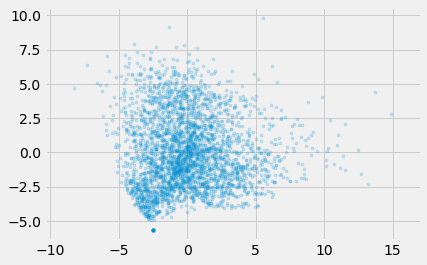

In [43]:
plt.scatter(X_pca[:,0], X_pca[:, 1], s=10, alpha=0.2)
plt.axis("equal")

In [44]:
kmeans = KMeans(n_clusters=4)
model = kmeans.fit(X)
labels = model.fit_predict(X)

In [45]:
centers = model.cluster_centers_
centers

array([[ 1.34332779,  0.88826644,  0.08476695,  0.10522456,  1.33922092,
         0.78301106,  0.17490657,  0.10524397,  1.32883254, -1.29069536,
        -0.84396955,  1.06553216, -0.75160784, -0.88113622, -0.93778379,
        -0.13975763,  0.39999331, -0.24666171,  0.3327438 ],
       [-0.40527829, -0.15214833,  0.20834562,  0.0389165 , -0.38589689,
        -0.14511733,  0.17977641,  0.20156279, -0.36402026,  0.29596752,
         0.42449551, -0.37822555,  0.27135546,  0.38711627,  0.20453047,
         0.13800035, -0.06196515,  0.12207081, -0.03232609],
       [-0.48882448,  0.56521645,  1.52891396,  1.37725283, -0.42193999,
         0.66533714,  1.46689859,  1.49691393, -0.35213417,  0.50859346,
         1.52423718, -1.23194681,  1.33198298,  1.49027781,  0.92640552,
         1.69392022,  1.43924363,  1.46654168, -0.29592519],
       [-0.59186731, -1.00213636, -1.14906619, -0.8723973 , -0.64742888,
        -0.9559228 , -1.17184204, -1.1445643 , -0.70132768,  0.66912699,
        -0.479

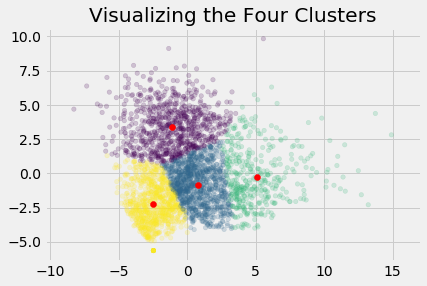

In [46]:
centers_pca = KMeans(n_clusters=4).fit(X_pca).cluster_centers_
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=20, cmap="viridis", alpha=0.2)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="red", cmap="viridis")
plt.axis("equal")
plt.title("Visualizing the Four Clusters")
plt.savefig('4clusters_scatter.png')

In [47]:
def pd_centers(featuresUsed, centers):
    colNames = list(featuresUsed)
    colNames.append('prediction')
    # Zip with a column called 'prediction' (index)
    Z = [np.append(A, index) for index, A in enumerate(centers)]
    # Convert to pandas data frame for plotting
    P = pd.DataFrame(Z, columns=colNames)
    P['prediction'] = P['prediction'].astype(int)
    return P

In [48]:
P = pd_centers(co2016_main.columns, centers)
P

,Trump,Johnson,Clinton,Stein,Glenn[R],Williams[I],Bennet[D],Madden[D],Ganahl[R],69,70,71,72,T,U,106,107,108,Turnout,prediction
0,1.343328,0.888266,0.084767,0.105225,1.339221,0.783011,0.174907,0.105244,1.328833,-1.290695,-0.843970,1.065532,-0.751608,-0.881136,-0.937784,-0.139758,0.399993,-0.246662,0.332744,0
1,-0.405278,-0.152148,0.208346,0.038916,-0.385897,-0.145117,0.179776,0.201563,-0.364020,0.295968,0.424496,-0.378226,0.271355,0.387116,0.204530,0.138000,-0.061965,0.122071,-0.032326,1
2,-0.488824,0.565216,1.528914,1.377253,-0.421940,0.665337,1.466899,1.496914,-0.352134,0.508593,1.524237,-1.231947,1.331983,1.490278,0.926406,1.693920,1.439244,1.466542,-0.295925,2
3,-0.591867,-1.002136,-1.149066,-0.872397,-0.647429,-0.955923,-1.171842,-1.144564,-0.701328,0.669127,-0.479303,0.042038,-0.275874,-0.375530,0.210678,-0.915069,-1.074696,-0.667525,-0.143740,3


In [49]:
P.mean(axis=1)

0    0.142973
1    0.077358
2    0.834548
3   -0.412322
dtype: float64

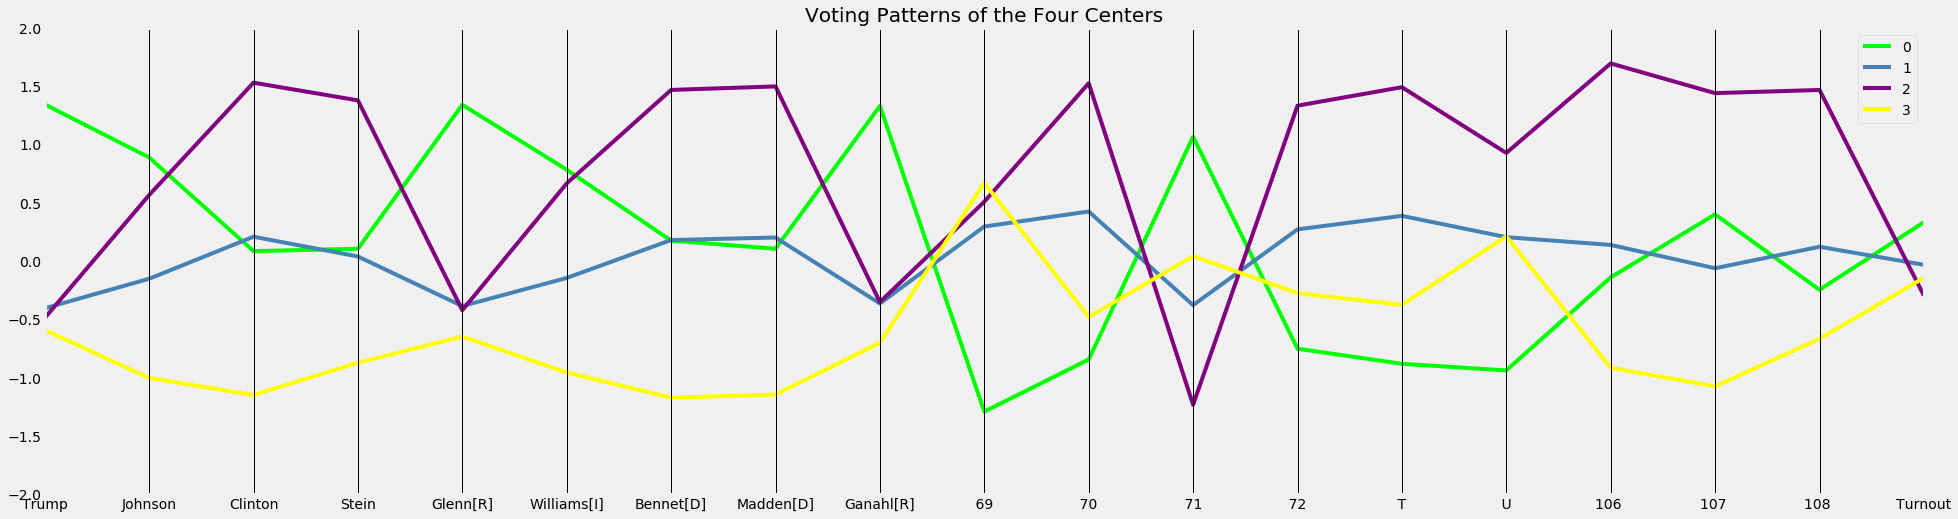

In [55]:
def parallel_plot(data):
    # my_colors = list(islice(cycle(['b', 'r', 'g', 'y', 'k']), None, len(data)))
    plt.figure(figsize=(30,8)).gca().axes.set_ylim([-2,+2])
    parallel_coordinates(data, 'prediction', color=["lime", "steelblue", "purple", "yellow"])
parallel_plot(P)
plt.title("Voting Patterns of the Four Centers")
plt.savefig('4clusters_line.png')

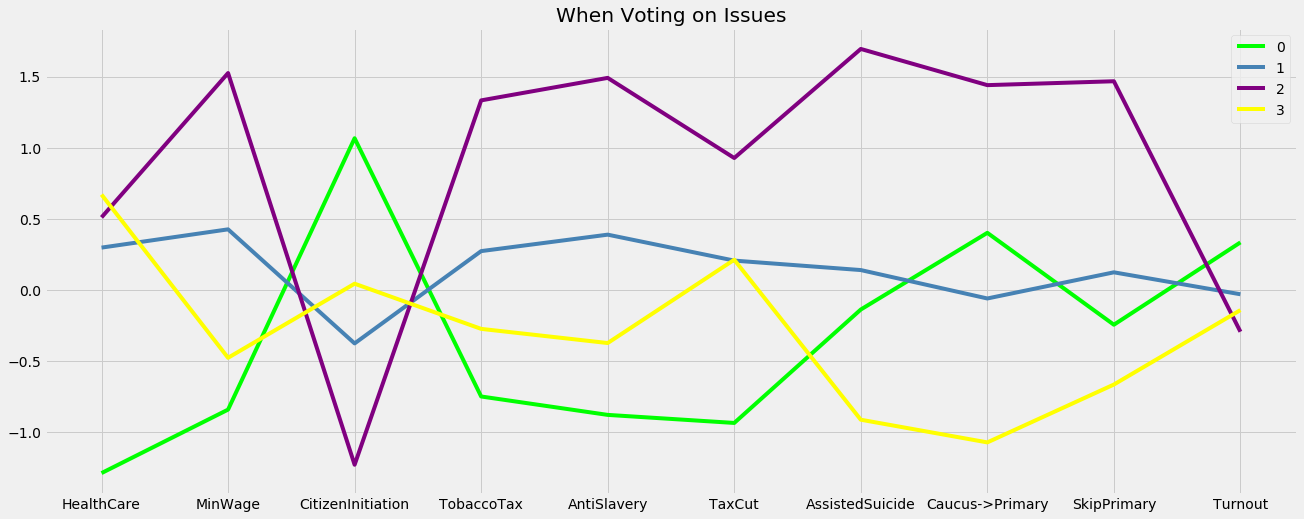

In [69]:
issues = [' 69 ', ' 70 ', ' 71 ', ' 72 ',
       ' T ', ' U ', '106 ', '107 ', '108 ', 'Turnout']
y_issues = P.loc[:,' 69 ':"Turnout"]
plt.figure(figsize=(20,8))
plt.plot(sorted(issues), y_issues.iloc[0], "lime")
plt.plot(sorted(issues), y_issues.iloc[1], "steelblue")
plt.plot(sorted(issues), y_issues.iloc[2], "purple")
plt.plot(sorted(issues), y_issues.iloc[3], "yellow")
plt.xticks(np.arange(10), ("HealthCare", "MinWage", "CitizenInitiation", "TobaccoTax", "AntiSlavery", "TaxCut", "AssistedSuicide", "Caucus->Primary", "SkipPrimary", "Turnout"))
plt.legend()
plt.title("When Voting on Issues")
plt.savefig('4clusters_issues.png')

In [52]:
y_issues

,69,70,71,72,T,U,106,107,108,Turnout
0,-1.290695,-0.843970,1.065532,-0.751608,-0.881136,-0.937784,-0.139758,0.399993,-0.246662,0.332744
1,0.295968,0.424496,-0.378226,0.271355,0.387116,0.204530,0.138000,-0.061965,0.122071,-0.032326
2,0.508593,1.524237,-1.231947,1.331983,1.490278,0.926406,1.693920,1.439244,1.466542,-0.295925
3,0.669127,-0.479303,0.042038,-0.275874,-0.375530,0.210678,-0.915069,-1.074696,-0.667525,-0.143740


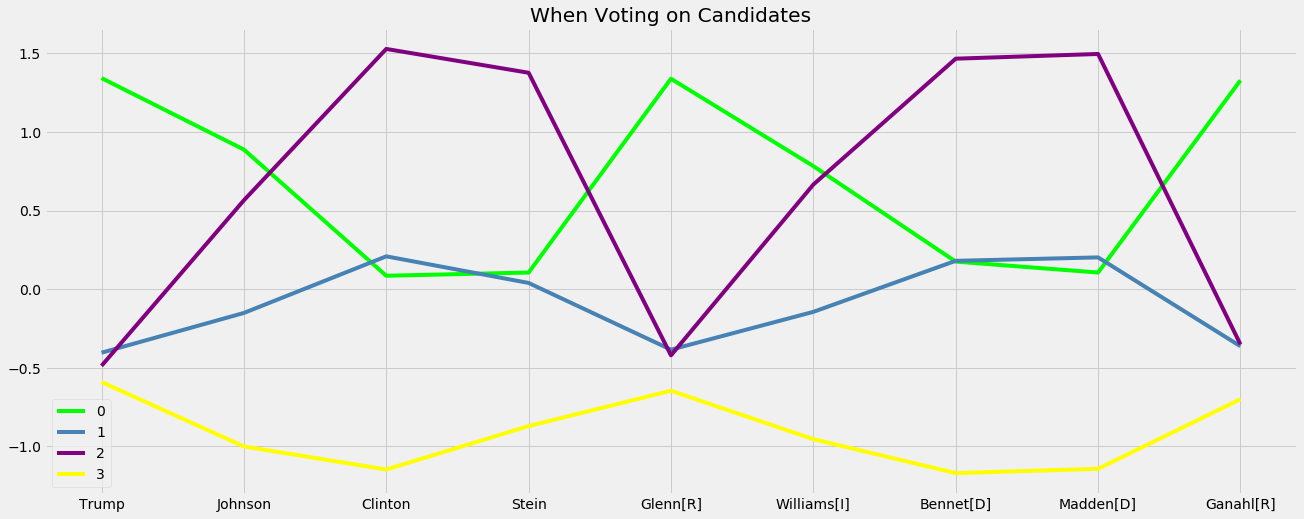

In [70]:
candidates = ['Trump', 'Johnson', 'Clinton', 'Stein', 'Glenn[R]', 'Williams[I]',
       'Bennet[D]', 'Madden[D]', 'Ganahl[R]']
y_candidates = P.loc[:,'Trump':'Ganahl[R]']
plt.figure(figsize=(20,8))
plt.plot(sorted(candidates), y_candidates.iloc[0], "lime")
plt.plot(sorted(candidates), y_candidates.iloc[1], "steelblue")
plt.plot(sorted(candidates), y_candidates.iloc[2], "purple")
plt.plot(sorted(candidates), y_candidates.iloc[3], "yellow")
plt.xticks(np.arange(9), ('Trump', 'Johnson', 'Clinton', 'Stein', 'Glenn[R]', 'Williams[I]',
       'Bennet[D]', 'Madden[D]', 'Ganahl[R]'))
plt.legend()
plt.title("When Voting on Candidates")
plt.savefig('4clusters_candidates.png')

In [54]:
y_candidates

,Trump,Johnson,Clinton,Stein,Glenn[R],Williams[I],Bennet[D],Madden[D],Ganahl[R]
0,1.343328,0.888266,0.084767,0.105225,1.339221,0.783011,0.174907,0.105244,1.328833
1,-0.405278,-0.152148,0.208346,0.038916,-0.385897,-0.145117,0.179776,0.201563,-0.364020
2,-0.488824,0.565216,1.528914,1.377253,-0.421940,0.665337,1.466899,1.496914,-0.352134
3,-0.591867,-1.002136,-1.149066,-0.872397,-0.647429,-0.955923,-1.171842,-1.144564,-0.701328


## Discussion ##

* **Amendment T** removes language like slavery from constitution. Cluster 1 and 2 have no strong opinion about this. Cluster 3 (Clinton enthusiasts) strongly favor it.
* **Amendment U** is a tax cut measure. 
* **69**: health care. tax increase. Clinton enthusiasts and Clinton haters converge on this issue.
* **70**: minimum wage increase. 
* **71**: increase threshold for citizen initiated constitutational referenda
* **72**: tobacco tax increase
* **106**: Aid-in-dying. 
* **107**: change caucus to primary
* **108**: allow unaffiliated voters to vote in primary. allow political parties to skip primary